## Step 1. Tokenization

In [17]:
from nltk import sent_tokenize, word_tokenize
import nltk
from nltk.stem import LancasterStemmer, WordNetLemmatizer

In [18]:
nltk.download("punkt_tab") # 마침표, 개행문자 등 특수기호

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [19]:
text_sample = "Are you a girl? I am a boy, I am not a girl. You are not a boy."

In [20]:
sentences = sent_tokenize(text_sample) # punkt_tab 기반으로 문장 분리
print(sentences)

['Are you a girl?', 'I am a boy, I am not a girl.', 'You are not a boy.']


In [21]:
word_token = []

for sentence in sentences :
    word_token.append(word_tokenize(sentence))

for words in word_token :
    print(words)

['Are', 'you', 'a', 'girl', '?']
['I', 'am', 'a', 'boy', ',', 'I', 'am', 'not', 'a', 'girl', '.']
['You', 'are', 'not', 'a', 'boy', '.']


## Step 2. Stemming / Lemmatization

In [22]:
stemmer = LancasterStemmer()
lemma = WordNetLemmatizer()

In [23]:
from nltk.stem import LancasterStemmer

print(stemmer.stem("love"), stemmer.stem("loved"), stemmer.stem("loving"))
print(stemmer.stem("have"), stemmer.stem("had"), stemmer.stem("having"))
print(stemmer.stem("learn"), stemmer.stem("learnt"), stemmer.stem("learned"), stemmer.stem("learning"))

print(stemmer.stem("happy"), stemmer.stem("happier"), stemmer.stem("happiest"))
print(stemmer.stem("good"), stemmer.stem("better"), stemmer.stem("best"))

lov lov lov
hav had hav
learn learnt learn learn
happy happy happiest
good bet best


In [24]:
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")


print(lemma.lemmatize("love", "v"), lemma.lemmatize("loved", "v"), lemma.lemmatize("loving", "v"))
print(lemma.lemmatize("have", "v"), lemma.lemmatize("had", "v"), lemma.lemmatize("having", "v"))
print(lemma.lemmatize("learn", "v"), lemma.lemmatize("learnt", "v"), lemma.lemmatize("learned", "v"), lemma.lemmatize("learning", "v"))

print(lemma.lemmatize("happy", "a"), lemma.lemmatize("happier", "a"), lemma.lemmatize("happiest", "a"))
print(lemma.lemmatize("good", "a"), lemma.lemmatize("better", "a"), lemma.lemmatize("best", "a"))

love love love
have have have
learn learn learn learn
happy happy happy
good good best


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 3. The Overall Process

In [25]:
sample1 = "I am a boy."
sample2 = "I am not a girl."
sample3 = "I am a girl."
sample4 = "I am a boy not a girl."
sample5 = "Boy and Girl"

sentences = [sample1, sample2, sample3, sample4, sample5]

### Step 3-1. Text Preprocessing

In [26]:
word_token = []

for sentence in sentences :
    word_token.append(word_tokenize(sentence))

for word in word_token :
    print(word)

['I', 'am', 'a', 'boy', '.']
['I', 'am', 'not', 'a', 'girl', '.']
['I', 'am', 'a', 'girl', '.']
['I', 'am', 'a', 'boy', 'not', 'a', 'girl', '.']
['Boy', 'and', 'Girl']


In [27]:
### 소문자화

for i in range (len(word_token)) :
    for j in range (len(word_token[i])) :
        word_token[i][j] = word_token[i][j].lower()

print(word_token)

[['i', 'am', 'a', 'boy', '.'], ['i', 'am', 'not', 'a', 'girl', '.'], ['i', 'am', 'a', 'girl', '.'], ['i', 'am', 'a', 'boy', 'not', 'a', 'girl', '.'], ['boy', 'and', 'girl']]


In [28]:
### 문장부호 제거

punctuation = [".", ",", "!", "?"]

for i in range (len(word_token)) :
    word = []

    for j in range (len(word_token[i])) :
        if word_token[i][j] not in punctuation :
            word.append(word_token[i][j])

    word_token[i] = word

print(word_token)

[['i', 'am', 'a', 'boy'], ['i', 'am', 'not', 'a', 'girl'], ['i', 'am', 'a', 'girl'], ['i', 'am', 'a', 'boy', 'not', 'a', 'girl'], ['boy', 'and', 'girl']]


In [29]:
### Lemmatization

for i in range (len(word_token)) :
    for j in range (len(word_token[i])) :
        word_token[i][j] = lemma.lemmatize(word_token[i][j], "v")

print(word_token)

[['i', 'be', 'a', 'boy'], ['i', 'be', 'not', 'a', 'girl'], ['i', 'be', 'a', 'girl'], ['i', 'be', 'a', 'boy', 'not', 'a', 'girl'], ['boy', 'and', 'girl']]


### Step 3-2. 숫자화 (Encoding)

In [30]:
vocab = {}
for sentence in word_token :
    for token in sentence :
        if token not in vocab :
            vocab[token] = len(vocab) + 1

print(vocab)  #단어 숫자 매핑

{'i': 1, 'be': 2, 'a': 3, 'boy': 4, 'not': 5, 'girl': 6, 'and': 7}


In [31]:
### Method :: Integer Encoding
# 장점: 가장 단순 ; 단점: 숫자 자체에 의미가 없음, 문장마다 길이가 다름

integer_encoded_sentences = []
for sentence in word_token :
    encoded = [vocab[token] for token in sentence]
    integer_encoded_sentences.append(encoded)

print("Integer Encoding \n")
for i in range (len(word_token[1])) :
    print(f"{word_token[1][i]:5} -> {integer_encoded_sentences[1][i]}")

Integer Encoding 

i     -> 1
be    -> 2
not   -> 5
a     -> 3
girl  -> 6


In [32]:
### Method :: One-hot Encoding
# 장점: 구조 단순 ; 단점: 행렬 - 메모리가 크다

def one_hot (index, vocab_size) :
    vector = [0] * vocab_size
    vector[index - 1] = 1
    return vector

vocab_size = len(vocab)

print("One-hot Encoding \n")
for i in range (len(word_token[1])) :
    print(f"{word_token[1][i]:5} -> {one_hot(vocab[word_token[1][i]], vocab_size)}")

One-hot Encoding 

i     -> [1, 0, 0, 0, 0, 0, 0]
be    -> [0, 1, 0, 0, 0, 0, 0]
not   -> [0, 0, 0, 0, 1, 0, 0]
a     -> [0, 0, 1, 0, 0, 0, 0]
girl  -> [0, 0, 0, 0, 0, 1, 0]


In [33]:
### Method 3 :: BoW
# 장점 : 문장마다 동일 길이 벡터, 빈도 계산에 적합 ; 단점 : 문맥의 유사성과 순서가 없음

from collections import Counter

count = Counter(word_token[1])
bow = [0] * len(vocab)
for token, freq in count.items() :
    bow[vocab[token] - 1] = freq

print("Bag of Words \n")
print(f"{word_token[1]}")
print(f"{bow}")

Bag of Words 

['i', 'be', 'not', 'a', 'girl']
[1, 1, 1, 0, 1, 1, 0]


### Step 3-3. Padding

In [34]:
print(integer_encoded_sentences)

[[1, 2, 3, 4], [1, 2, 5, 3, 6], [1, 2, 3, 6], [1, 2, 3, 4, 5, 3, 6], [4, 7, 6]]


In [35]:
for i in range (5) :
    print(sentences[i])
    print(integer_encoded_sentences[i])
    print()

I am a boy.
[1, 2, 3, 4]

I am not a girl.
[1, 2, 5, 3, 6]

I am a girl.
[1, 2, 3, 6]

I am a boy not a girl.
[1, 2, 3, 4, 5, 3, 6]

Boy and Girl
[4, 7, 6]



In [36]:
max_len = max([len(i) for i in integer_encoded_sentences])
print(max_len)

7


In [37]:
for sentence in integer_encoded_sentences :
    while (len(sentence) < max_len) :
        sentence.append(0)

In [38]:
print(integer_encoded_sentences)

[[1, 2, 3, 4, 0, 0, 0], [1, 2, 5, 3, 6, 0, 0], [1, 2, 3, 6, 0, 0, 0], [1, 2, 3, 4, 5, 3, 6], [4, 7, 6, 0, 0, 0, 0]]


### Step 3-4. 유사도 계산

In [39]:
### Method :: Cosine Similarity

from numpy import dot
from numpy.linalg import norm

def cos_similarity (A, B) :
  return dot(A, B) / (norm(A) * norm(B))

print(f"Target : {sentences[0]} \n")
for i in range(1, 5) :
    print(f"Compare : {sentences[i]:25} -> {cos_similarity(integer_encoded_sentences[0], integer_encoded_sentences[i])}")

Target : I am a boy. 

Compare : I am not a girl.          -> 0.6746192341692542
Compare : I am a girl.              -> 0.9811557810392123
Compare : I am a boy not a girl.    -> 0.5477225575051661
Compare : Boy and Girl              -> 0.6540051775614837


In [40]:
### Method :: Euclidean Distance

import numpy as np

def euclidean_distance (A, B) :
    return np.sqrt(np.sum(((np.array(A) - np.array(B)) ** 2)))

print(f"Target : {sentences[0]} \n")
for i in range(1, 5) :
    print(f"Compare : {sentences[i]:25} -> {euclidean_distance(integer_encoded_sentences[0], integer_encoded_sentences[i])}")

Target : I am a boy. 

Compare : I am not a girl.          -> 6.4031242374328485
Compare : I am a girl.              -> 2.0
Compare : I am a boy not a girl.    -> 8.366600265340756
Compare : Boy and Girl              -> 7.681145747868608


In [41]:
!pip -q install -U sentence-transformers

In [42]:
# @title
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = model.encode(sentences, normalize_embeddings=True)

print("=== Embedding Shape ===")
print(embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

=== Embedding Shape ===
(5, 384)


In [43]:
print("=== Cosine Similarity with Semantic Embeddings ===")

print(f"Target : {sentences[0]}\n")
for i in range(1, 5) :
    print(f"Compare : {sentences[i]:25} -> {cos_similarity(embeddings[0], embeddings[i])}")

=== Cosine Similarity with Semantic Embeddings ===
Target : I am a boy.

Compare : I am not a girl.          -> 0.696854293346405
Compare : I am a girl.              -> 0.7777857184410095
Compare : I am a boy not a girl.    -> 0.8184243440628052
Compare : Boy and Girl              -> 0.4199228286743164


In [44]:
print("=== 유클리드 거리 with Semantic Embeddings ===")

print(f"Target : {sentences[0]} \n")
for i in range(1, 5) :
    print(f"Compare : {sentences[i]:25} -> {euclidean_distance(embeddings[0], embeddings[i])}")

=== Cosine Similarity with Semantic Embeddings ===
Target : I am a boy. 

Compare : I am not a girl.          -> 0.7786473035812378
Compare : I am a girl.              -> 0.6666547656059265
Compare : I am a boy not a girl.    -> 0.6026206016540527
Compare : Boy and Girl              -> 1.0771045684814453


## Practice
텍스트 분석을 진행하여, 빈도수가 가장 높은 단어부터 낮은 단어 순으로 WordCloud를 이용해 시각화해주세요.  
### Sample. Movie Review

In [50]:
!pip -q install wordcloud nltk

In [51]:
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS

nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

lemma = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


positive: 1000
negative: 1000
=== Positive Top 10 ===
the             41357
be              26269
a               20145
and             19803
of              18549
to              16438
in              11623
's              9473
``              8494
it              8326

=== Negative Top 10 ===
the             34919
be              23160
a               17850
and             15601
of              15423
to              15334
in              9988
``              9131
's              8655
that            7797


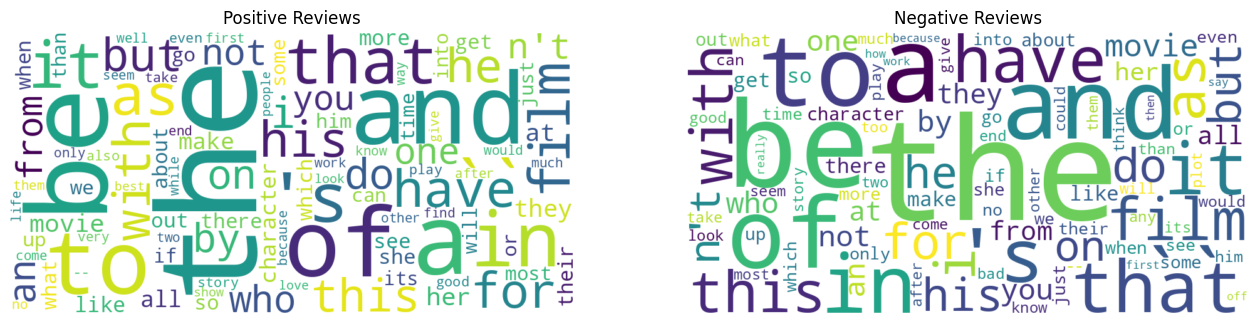

In [52]:
from nltk.corpus import movie_reviews
nltk.download("movie_reviews")

pos_fileids = movie_reviews.fileids("pos")
neg_fileids = movie_reviews.fileids("neg")

print("positive:", len(pos_fileids))
print("negative:", len(neg_fileids))

pos_text = " ".join([movie_reviews.raw(fileid) for fileid in pos_fileids])
neg_text = " ".join([movie_reviews.raw(fileid) for fileid in neg_fileids])

def preprocess_text(text) :
    # lower
    text = text.lower()

    # tokenization
    tokens = word_tokenize(text)

    # punctuation removal
    tokens = [token for token in tokens if token not in string.punctuation]

    # lemmatization
    tokens = [lemma.lemmatize(token, "v") for token in tokens]

    return tokens

pos_tokens = preprocess_text(pos_text)
neg_tokens = preprocess_text(neg_text)

pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

print("=== Positive Top 10 ===")
for word, count in pos_freq.most_common(10) :
    print(f"{word:15} {count}")

print("\n=== Negative Top 10 ===")
for word, count in neg_freq.most_common(10) :
    print(f"{word:15} {count}")

wc_pos = WordCloud(
    width=900,
    height=450,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=100
).generate_from_frequencies(pos_freq)

wc_neg = WordCloud(
    width=900,
    height=450,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=100
).generate_from_frequencies(neg_freq)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews")

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews")

plt.show()

### Task : I have a dream
preprocess_text 함수 사용하지 마세요!!

In [48]:
dream = """
I have a dream that one day this nation will rise up and live out the true meaning of its creed: "We hold these truths to be self-evident: that all men are created equal."
I have a dream that one day on the red hills of Georgia the sons of former slaves and the sons of former slave owners will be able to sit down together at the table of brotherhood.
I have a dream that one day even the state of Mississippi, a state sweltering with the heat of injustice, sweltering with the heat of oppression, will be transformed into an oasis of freedom and justice.
I have a dream that my four little children will one day live in a nation where they will not be judged by the color of their skin, but by the content of their character.
I have a dream today.
I have a dream that one day, down in Alabama, with its vicious racists, with its governor having his lips dripping with the words of interposition and nullification; one day right there in Alabama, little black boys and black girls will be able to join hands with little white boys and white girls as sisters and brothers.
I have a dream today.
I have a dream that one day every valley shall be exalted, every hill and mountain shall be made low, the rough places will be made plain, and the crooked places will be made straight, and the glory of the Lord shall be revealed, and all flesh shall see it together.
"""

In [54]:
# Step 1. lower
text = dream.lower()

In [55]:
# Step 2. tokenization
tokens = word_tokenize(text)

In [56]:
# Step 3. punctuation removal
tokens = [token for token in tokens if token not in string.punctuation]

In [57]:
# Step 4. lemmatization
tokens = [lemma.lemmatize(token, "v") for token in tokens]

In [58]:
print(tokens[:30])

['i', 'have', 'a', 'dream', 'that', 'one', 'day', 'this', 'nation', 'will', 'rise', 'up', 'and', 'live', 'out', 'the', 'true', 'mean', 'of', 'its', 'creed', '``', 'we', 'hold', 'these', 'truths', 'to', 'be', 'self-evident', 'that']


In [59]:
# Step 5. frequency count
freq = Counter(tokens)

# Step 6. Top 10 words
print("Top 10 words")
for word, count in freq.most_common(10) :
    print(f"{word:15} {count}")

Top 10 words
the             15
of              13
and             11
be              11
a               10
have            9
i               8
dream           8
will            8
that            7


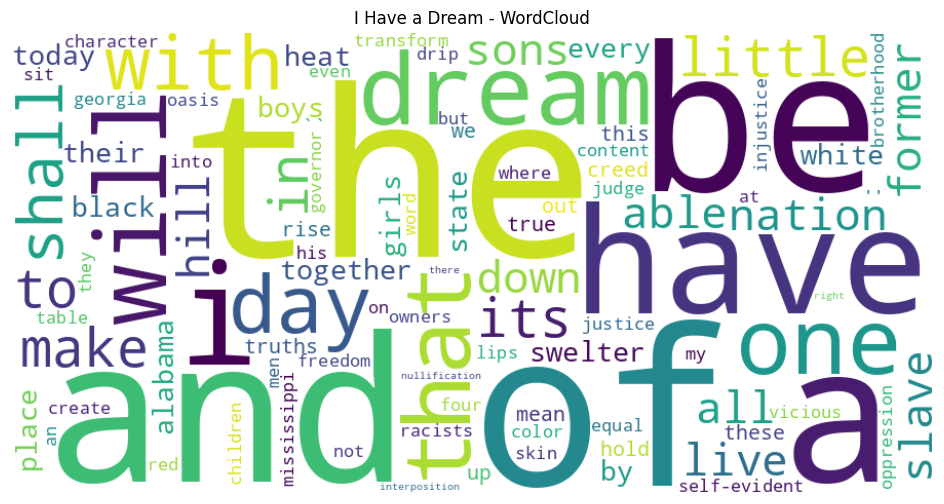

In [62]:
# Step 7. WordCloud
wc = WordCloud(
    width=900,
    height=450,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=100
).generate_from_frequencies(freq)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("I Have a Dream - WordCloud")
plt.show()